In [1]:
# Task 1: Data Cleaning & Preprocessing

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Basic information about the dataset

print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(891, 12)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare     

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# Handle missing values

# Fill missing Age values with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column because it has too many missing values
df.drop('Cabin', axis=1, inplace=True)

# Check missing values after handling
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [5]:
# Convert categorical columns into numerical values

# Encode Sex
df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

# One-hot encode Embarked
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True, dtype=int)

# Display encoded data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,1


In [6]:
# Remove unnecessary text columns

df.drop(['Name', 'Ticket'], axis=1, inplace=True)

print("Dataset after removing Name and Ticket:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

Dataset after removing Name and Ticket:


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,0,1
1,2,1,1,1,38.0,1,0,71.2833,0,0
2,3,1,3,1,26.0,0,0,7.9250,0,1
3,4,1,1,1,35.0,1,0,53.1000,0,1
4,5,0,3,0,35.0,0,0,8.0500,0,1



Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked_Q       int64
Embarked_S       int64
dtype: object


In [7]:
from sklearn.preprocessing import StandardScaler

# Columns to standardize
numerical_columns = ['Age', 'SibSp', 'Parch', 'Fare']

# Create StandardScaler
scaler = StandardScaler()

# Standardize numerical features
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Display scaled dataset
print("Dataset after Standardization:")
display(df.head())

Dataset after Standardization:


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,0,-0.565736,0.432793,-0.473674,-0.502445,0,1
1,2,1,1,1,0.663861,0.432793,-0.473674,0.786845,0,0
2,3,1,3,1,-0.258337,-0.474545,-0.473674,-0.488854,0,1
3,4,1,1,1,0.433312,0.432793,-0.473674,0.420730,0,1
4,5,0,3,0,0.433312,-0.474545,-0.473674,-0.486337,0,1


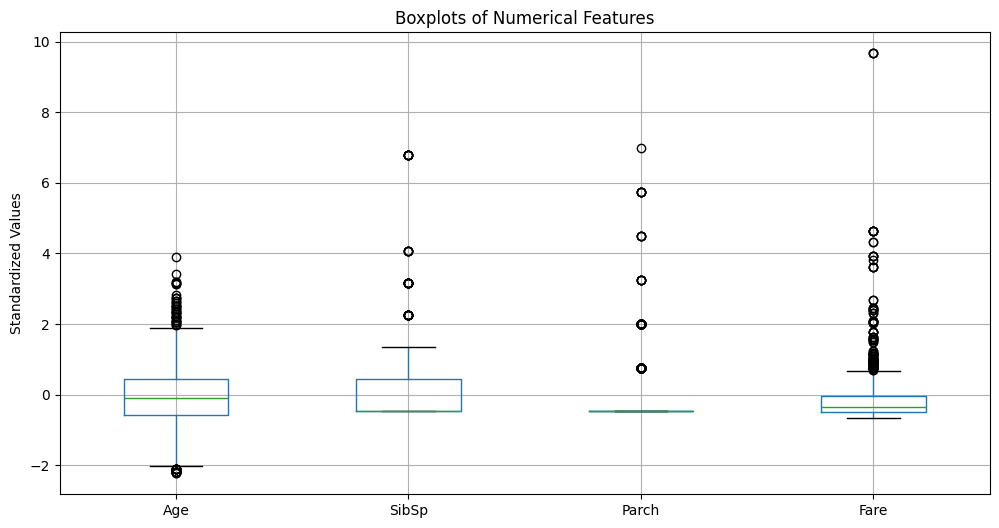

In [8]:
# Visualize outliers using boxplots

plt.figure(figsize=(12, 6))

df[['Age', 'SibSp', 'Parch', 'Fare']].boxplot()

plt.title("Boxplots of Numerical Features")
plt.ylabel("Standardized Values")
plt.show()

In [9]:
# Remove outliers using the IQR method

# Store number of rows before removing outliers
rows_before = df.shape[0]

# Columns for outlier removal
outlier_columns = ['Age', 'SibSp', 'Parch', 'Fare']

# Remove outliers from each numerical column
for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ]

# Store number of rows after removing outliers
rows_after = df.shape[0]

print("Rows before removing outliers:", rows_before)
print("Rows after removing outliers:", rows_after)
print("Outliers removed:", rows_before - rows_after)

Rows before removing outliers: 891
Rows after removing outliers: 561
Outliers removed: 330


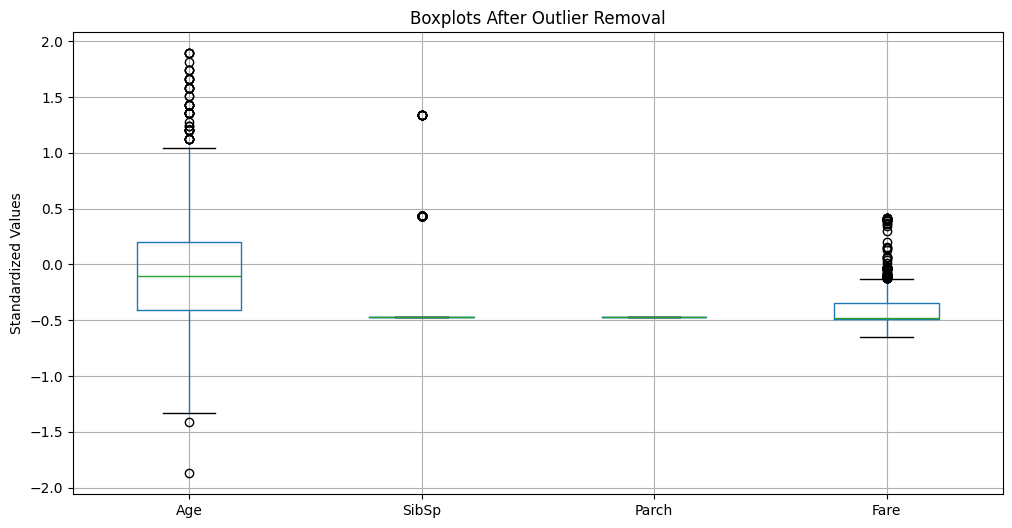

In [10]:
# Boxplots after outlier removal

plt.figure(figsize=(12, 6))

df[['Age', 'SibSp', 'Parch', 'Fare']].boxplot()

plt.title("Boxplots After Outlier Removal")
plt.ylabel("Standardized Values")

plt.show()

In [11]:
# Final dataset information

print("Final Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFinal Cleaned Dataset:")
display(df.head())

print("\nStatistical Summary:")
display(df.describe())

Final Dataset Shape: (561, 10)

Missing Values:
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked_Q     0
Embarked_S     0
dtype: int64

Final Cleaned Dataset:


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,0,-0.565736,0.432793,-0.473674,-0.502445,0,1
2,3,1,3,1,-0.258337,-0.474545,-0.473674,-0.488854,0,1
3,4,1,1,1,0.433312,0.432793,-0.473674,0.420730,0,1
4,5,0,3,0,0.433312,-0.474545,-0.473674,-0.486337,0,1
5,6,0,3,0,-0.104637,-0.474545,-0.473674,-0.478116,1,0



Statistical Summary:


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
count,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,5.610000e+02,561.000000,561.000000,561.000000
mean,448.946524,0.286988,2.520499,0.247772,-0.014637,-0.301488,-4.736736e-01,-0.372014,0.114082,0.750446
std,259.912212,0.452759,0.717155,0.432104,0.650385,0.399553,4.444855e-16,0.212633,0.318195,0.433141
min,1.000000,0.000000,1.000000,0.000000,-1.872184,-0.474545,-4.736736e-01,-0.648422,0.000000,0.000000
25%,221.000000,0.000000,2.000000,0.000000,-0.412037,-0.474545,-4.736736e-01,-0.491874,0.000000,1.000000
50%,452.000000,0.000000,3.000000,0.000000,-0.104637,-0.474545,-4.736736e-01,-0.478116,0.000000,1.000000
75%,675.000000,1.000000,3.000000,0.000000,0.202762,-0.474545,-4.736736e-01,-0.345395,0.000000,1.000000
max,891.000000,1.000000,3.000000,1.000000,1.893459,1.340132,-4.736736e-01,0.420730,1.000000,1.000000


In [12]:
display(df)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,0,-0.565736,0.432793,-0.473674,-0.502445,0,1
2,3,1,3,1,-0.258337,-0.474545,-0.473674,-0.488854,0,1
3,4,1,1,1,0.433312,0.432793,-0.473674,0.420730,0,1
4,5,0,3,0,0.433312,-0.474545,-0.473674,-0.486337,0,1
5,6,0,3,0,-0.104637,-0.474545,-0.473674,-0.478116,1,0
...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,0,-0.335187,-0.474545,-0.473674,-0.506472,0,1
886,887,0,2,0,-0.181487,-0.474545,-0.473674,-0.386671,0,1
887,888,1,1,1,-0.796286,-0.474545,-0.473674,-0.044381,0,1
889,890,1,1,0,-0.258337,-0.474545,-0.473674,-0.044381,0,0


In [13]:
# Save the final cleaned dataset
df.to_csv("/kaggle/working/cleaned_titanic.csv", index=False)

print("File saved successfully!")

File saved successfully!
